<a href="https://colab.research.google.com/github/lmf55/RNA-e-Deep-Learning---CESAR-School-2025.02/blob/main/Atividade%20Aula%204.2/Atividade_Aula_4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rede neural com camadas escondidas - Classificação do Iris dataset

O objetivo desse experimento é ilustrar o uso de rede neural que tenha mais de uma camada. Isso é conseguido com a inserção de uma ativação não linear entre as camadas.

Datasets utilizados:
    - Iris - 3 classes
    - Sintéticos:
        - meia luas
        - círculos circunscritos
        - blobs

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/Net2RegressaoSoftmaxArgmaxRede.png)

## Importando as bibliotecas

In [114]:
%matplotlib inline
from sklearn import datasets
from IPython import display
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn

## Leitura, normalização e visualização dos dados

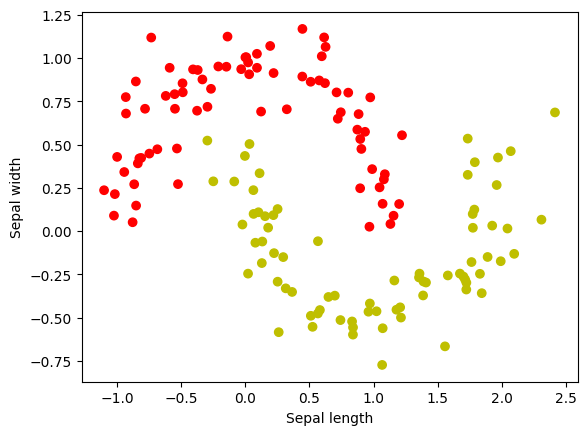

In [115]:
n_samples = 150
options = ['iris', 'moon', 'circles', 'blobs']
option = options[1]
if option == 'iris':
    iris = datasets.load_iris()
    X = iris.data[:,:2]  # comprimento das sépalas e pétalas, indices 0 e 2
    Xc = X - X.min(axis=0)
    Xc /= Xc.max(axis=0)
    Y = iris.target
elif option == 'moon':
    Xc,Y = datasets.make_moons(n_samples=n_samples, noise=.15)
elif option == 'circles':
    Xc,Y = datasets.make_circles(n_samples=n_samples, factor=.5, noise=.1)
elif option == 'blobs':
    Xc,Y = datasets.make_blobs(n_samples=n_samples,centers=3,cluster_std=1.2)

colors = np.array(['r','y','b'])
plt.scatter(Xc[:, 0], Xc[:, 1], c=colors[Y])
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show()

### Prepara os dados para o PyTorch

In [116]:
X_tensor = torch.FloatTensor(Xc)
Y_tensor = torch.LongTensor(Y)

## Construindo o modelo da rede

In [117]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 5),
            nn.ReLU(),
            nn.Linear(5, 5),
            nn.ReLU(),
            nn.Linear(5,3),
        )

    def forward(self, x):
        x = self.dense(x)

        return x

model = Modelo()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=5, bias=True)
    (3): ReLU()
    (4): Linear(in_features=5, out_features=3, bias=True)
  )
)


## _predict_ utilizada para predição de classes e na visualização

In [118]:
def predict(model, inputs):
    outputs = model(Variable(inputs))
    _, predicts = torch.max(outputs, 1)

    return predicts.data.numpy()

## Classe para visualização dinâmica

In [119]:
class BoundaryPlotter():
    def __init__(self, model, X, Y, n_epoch, filepath=None, h = .01):
        self.model = model
        self.X = X
        self.Y = Y
        self.n_epoch = n_epoch
        self.filepath = filepath
        x_min, x_max = X[:, 0].min() - .5, X[:, 0].max() + .5
        y_min, y_max = X[:, 1].min() - .5, X[:, 1].max() + .5
        self.xx, self.yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        self.loss_hist = []
        self.val_loss_hist = []
        self.X_grid = np.c_[self.xx.ravel(), self.yy.ravel()]

        #Gráficos a serem mostrados pelo callback
        self.fig = plt.figure(figsize=(8, 4), dpi=100)
        self.ax1 = self.fig.add_subplot(1, 2, 1)
        self.ax1.set_xlim(0, self.n_epoch)
        self.ax1.set_xlabel('Epoca')#,fontsize=28)
        self.ax1.set_ylabel('Perda')#,fontsize=28)
        self.ax1.plot([],[],'b',linewidth = 2.0,label = "Treino")
        self.ax1.grid(True)

        self.ax2 = self.fig.add_subplot(1, 2, 2)
        self.ax2.set_xlim(self.X[:,0].min(), self.X[:,0].max())
        self.ax2.set_ylim(self.X[:,1].min(), self.X[:,1].max())
        self.ax2.set_xlabel('Comprimento da Sepala')#,fontsize=28)
        self.ax2.set_ylabel('Largura da Sepala')#,fontsize=28)

    def on_train_begin(self, logs={}):
        display.display(self.fig)
        display.clear_output(wait=True)

    def on_epoch_end(self, epoch, logs={}):
        if 'loss' in logs.keys():
            self.loss_hist.append(logs['loss'])

            if epoch%250==0:
                self.ax1.plot(np.arange(epoch+1), self.loss_hist, 'b', linewidth = 2.0)

                Z = predict(self.model, torch.from_numpy(self.X_grid).type(torch.FloatTensor))
#                 Z = torch.max(self.model(Variable(torch.FloatTensor(self.X_grid))).data, dim=1)[1].numpy()
                Z = Z.reshape(self.xx.shape)

                self.ax2.pcolormesh(self.xx, self.yy, Z, cmap=plt.cm.Paired)
                colors = np.array(['r','y','b'])
                self.ax2.scatter(self.X[:, 0], self.X[:, 1], s=40, c=colors[self.Y], edgecolors='k', cmap=plt.cm.Paired)

                display.display(self.fig)
                display.clear_output(wait=True)

## Treinamento

In [120]:
lr = 0.15

optimizer = torch.optim.SGD(model.parameters(), lr=lr)

criterion = nn.CrossEntropyLoss()

### Laço principal de treinamento

Final loss: tensor(0.2564)


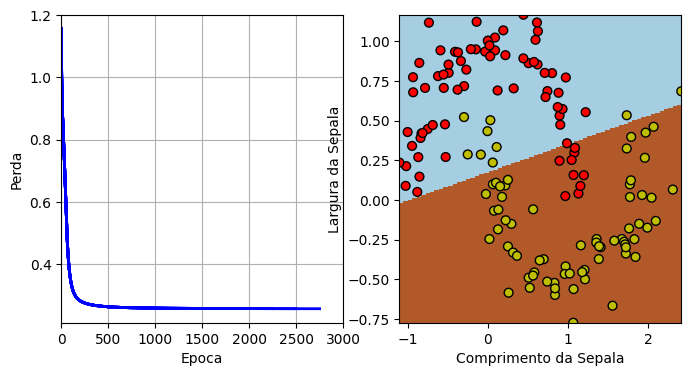

In [121]:
batch_size = 150
nb_epoch = 3000

#Definindo o plotter
boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)

boundary_plot.on_train_begin()
losses = []
for i in range(nb_epoch):
    # predict da rede
    output = model(Variable(X_tensor))

    loss = criterion(output, Variable(Y_tensor))

    # zero, backpropagation gradient, atualiza param gradiente descendente
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data)

    boundary_plot.on_epoch_end(i, {'loss': loss.data})

print('Final loss:', loss.data)

## Avaliação

### Imprimindo pesos finais

In [122]:
for name, w in model.state_dict().items():
    print('{:16}{}'.format(name, w.size()))
    print(w)

dense.0.weight  torch.Size([5, 2])
tensor([[-0.0965,  0.1073],
        [-0.1632, -0.5711],
        [-0.0136,  1.0681],
        [-0.3267,  1.2359],
        [ 0.1076, -0.3505]])
dense.0.bias    torch.Size([5])
tensor([-0.5879, -0.3613,  0.5858,  1.0110,  0.3850])
dense.2.weight  torch.Size([5, 5])
tensor([[-0.4064,  0.0472,  0.5513,  1.0995, -0.2977],
        [-0.2357, -0.2153,  0.0594,  0.0370,  0.0551],
        [-0.0814, -0.3582,  0.1784, -0.4180, -0.0976],
        [ 0.1643,  0.2214,  0.8521,  1.1297, -0.1361],
        [-0.3326,  0.3279,  0.3390, -0.0913,  0.2533]])
dense.2.bias    torch.Size([5])
tensor([ 0.1557, -0.1381, -0.1427, -0.0290, -0.4405])
dense.4.weight  torch.Size([3, 5])
tensor([[ 0.6254, -0.3536, -0.1965,  1.3127,  0.3161],
        [-0.4974, -0.4349,  0.1554, -0.2195,  0.2011],
        [-1.0516,  0.3521,  0.3229, -0.4996,  0.1798]])
dense.4.bias    torch.Size([3])
tensor([-1.2751,  3.8058, -2.4287])


### Avaliação do classificador

In [123]:
Y_hat = predict(model, X_tensor)
accuracy = (Y_hat == Y).mean()
print()
print('Training Accuracy: ', accuracy)


Training Accuracy:  0.88


### Matriz de confusão

In [124]:
import pandas as pd
pd.crosstab(Y_hat, Y)

col_0,0,1
row_0,,
0,66,9
1,9,66


## Atividades

### Experimentos:

1. Faça alterações na rede, alterando o número de neurônios, de camadas. Escreva suas conclusões.
2. No lugar da ReLU, coloque Sigmoid e observe a diferença. O que aconteceu? Descreva.
3. O que ocorre quando não se utiliza ativação não linear entre camadas?

In [125]:
def treinar_e_avaliar(model, nome_modelo, X_tensor, Y_tensor, Xc, Y, nb_epoch=3000, lr=0.15):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    boundary_plot = BoundaryPlotter(model, Xc, Y, nb_epoch)
    boundary_plot.on_train_begin()

    losses = []

    for i in range(nb_epoch):
        output = model(X_tensor)
        loss = criterion(output, Y_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())
        boundary_plot.on_epoch_end(i, {'loss': loss.item()})

    Y_hat = predict(model, X_tensor)
    accuracy = (Y_hat == Y).mean()

    print(nome_modelo)
    print('Final loss:', losses[-1])
    print('Training Accuracy:', accuracy)

    matriz = pd.crosstab(
        pd.Series(Y_hat, name='Predito'),
        pd.Series(Y, name='Real')
    )

    print('\nMatriz de confusão:')
    print(matriz)

    return losses, accuracy, matriz

## Principais aprendizados

### Experimento 1: Alterando neurônios e camadas

Código da rede testada, treinamento, acurácia e matriz de confusão.

Conclusão: ...

Experimento 1 - Rede maior com ReLU
Final loss: 0.004541417118161917
Training Accuracy: 1.0

Matriz de confusão:
Real      0   1
Predito        
0        75   0
1         0  75


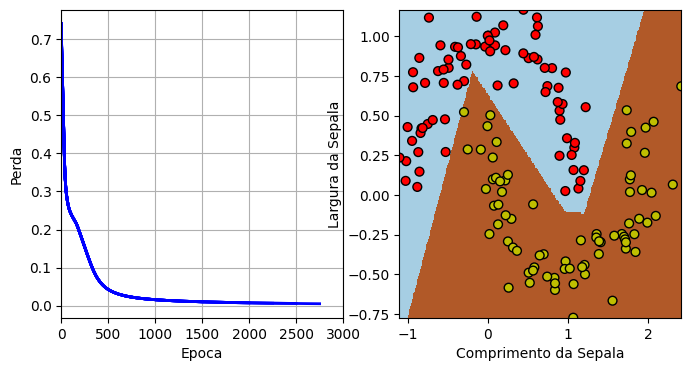

In [126]:
#1
class ModeloReluMaior(nn.Module):
    def __init__(self):
        super(ModeloReluMaior, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 2),
        )

    def forward(self, x):
        return self.dense(x)

model_relu_maior = ModeloReluMaior()

loss_relu_maior, acc_relu_maior, matriz_relu_maior = treinar_e_avaliar(
    model_relu_maior,
    'Experimento 1 - Rede maior com ReLU',
    X_tensor,
    Y_tensor,
    Xc,
    Y)

In [127]:
lr = 0.15
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

In [128]:
class Modelo(nn.Module):
    def __init__(self):
        super(Modelo, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 2),
        )

    def forward(self, x):
        x = self.dense(x)
        return x

model = Modelo()
print(model)

Modelo(
  (dense): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=2, bias=True)
  )
)


#1.
Ao aumentar o número de neurônios e camadas, a rede ganhou maior capacidade de aprender uma fronteira de decisão mais flexível, adequada ao padrão não linear do dataset moon.

Experimento 2 - Rede com Sigmoid
Final loss: 0.24677497148513794
Training Accuracy: 0.88

Matriz de confusão:
Real      0   1
Predito        
0        65   8
1        10  67


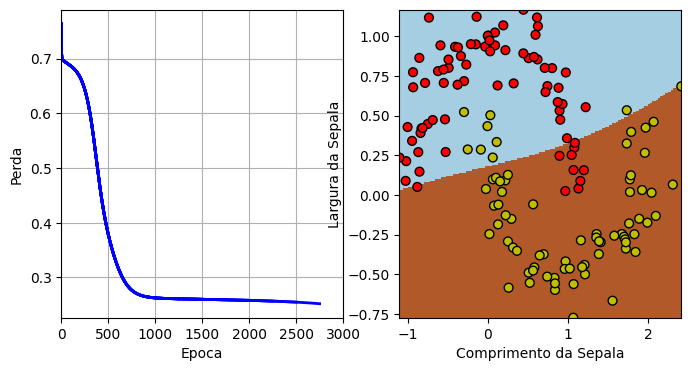

In [129]:
#2
class ModeloSigmoid(nn.Module):
    def __init__(self):
        super(ModeloSigmoid, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 10),
            nn.Sigmoid(),
            nn.Linear(10, 10),
            nn.Sigmoid(),
            nn.Linear(10, 2),
        )

    def forward(self, x):
        return self.dense(x)

model_sigmoid = ModeloSigmoid()

loss_sigmoid, acc_sigmoid, matriz_sigmoid = treinar_e_avaliar(
    model_sigmoid,
    'Experimento 2 - Rede com Sigmoid',
    X_tensor,
    Y_tensor,
    Xc,
    Y)

#2.
Ao substituir ReLU por Sigmoid, a rede ainda consegue aprender uma fronteira não linear, mas o treinamento pode ficar mais lento.

A Sigmoid comprime os valores entre 0 e 1. Isso pode reduzir a intensidade dos gradientes, especialmente em redes mais profundas, dificultando a atualização dos pesos.

Já a ReLU costuma treinar de forma mais eficiente, pois mantém gradientes mais fortes para valores positivos.

Experimento 3 - Rede sem ativação não linear
Final loss: 0.2557087242603302
Training Accuracy: 0.88

Matriz de confusão:
Real      0   1
Predito        
0        66   9
1         9  66


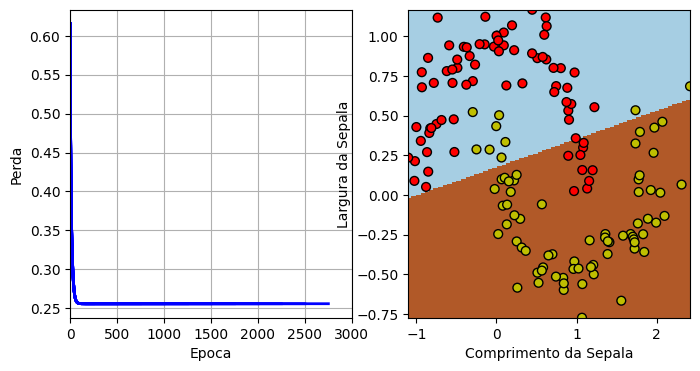

In [130]:
#3
class ModeloSemAtivacao(nn.Module):
    def __init__(self):
        super(ModeloSemAtivacao, self).__init__()
        self.dense = nn.Sequential(
            nn.Linear(2, 10),
            nn.Linear(10, 10),
            nn.Linear(10, 2),
        )

    def forward(self, x):
        return self.dense(x)

model_sem_ativacao = ModeloSemAtivacao()

loss_sem_ativacao, acc_sem_ativacao, matriz_sem_ativacao = treinar_e_avaliar(
    model_sem_ativacao,
    'Experimento 3 - Rede sem ativação não linear',
    X_tensor,
    Y_tensor,
    Xc,
    Y)

#3.
Quando removemos as ativações não lineares entre as camadas, a rede perde a capacidade de aprender padrões realmente não lineares.

Mesmo com várias camadas lineares em sequência, a composição de funções lineares continua sendo equivalente a uma única transformação linear.

Por isso, a fronteira de decisão tende a ser linear, semelhante à regressão logística simples, e pode não separar bem datasets como moon ou circles.

In [131]:
resultados = pd.DataFrame({
    'Modelo': [
        'ReLU - rede maior',
        'Sigmoid',
        'Sem ativação não linear'
    ],
    'Acurácia': [
        acc_relu_maior,
        acc_sigmoid,
        acc_sem_ativacao
    ],
    'Loss final': [
        loss_relu_maior[-1],
        loss_sigmoid[-1],
        loss_sem_ativacao[-1]
    ]
})

resultados

,Modelo,Acurácia,Loss final
0,ReLU - rede maior,1.00,0.004541
1,Sigmoid,0.88,0.246775
2,Sem ativação não linear,0.88,0.255709


#Conclusão
Nesta atividade, foi possível observar a importância das camadas escondidas e das funções de ativação em redes neurais.

Ao aumentar a quantidade de neurônios e camadas, a rede passou a ter maior capacidade
de representar padrões complexos.

A ReLU apresentou comportamento adequado para aprender fronteiras não lineares,
enquanto a Sigmoid também funcionou, mas pode apresentar treinamento mais lento.

Sem função de ativação não linear entre as camadas, a rede se comporta como um modelo linear, mesmo possuindo várias camadas. Por isso, a não linearidade é essencial para que redes neurais profundas aprendam padrões mais complexos.